# CNN + LSTM Autoencoder on Raw EEG (Unsupervised)

This notebook builds a 1D-CNN + LSTM autoencoder to learn temporal and frequency representations from unlabeled EEG signals.

It constructs the cleaned DataFrames expected elsewhere in the project: `clean_serie1`, `clean_serie11`, `cleaan_serie2` (intentional name per request), `clean_serie21`, `clean_serie3`, `clean_serie31`.

We then window the multichannel time series, train an unsupervised autoencoder, and visualize hidden temporal states that may correspond to stress variations using latent embeddings and reconstruction error.

Note: This notebook is self-contained and loads data from the `data/` directory.

In [1]:
# Imports
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

print(tf.__version__)
sns.set(style='whitegrid')

2.19.0


## Load and Clean EEG CSVs into the requested DataFrames
We load the six CSVs available in `data/` and create the cleaned DataFrames with the expected variable names.

In [4]:
import pandas as pd
import numpy as np

file_serie1 = 'data/skytt1serie1.csv'  # Replace it with your file path
file_serie2 = 'data/skytt1serie2.csv'
file_serie3 = 'data/skytt1serie3.csv'

file_serie11 = 'data/skytt2serie1.csv'  # Replace it with your file path
file_serie21 = 'data/skytt2serie2.csv'
file_serie31 = 'data/skytt2serie3.csv'

In [5]:
raw_serie1 = pd.read_csv(file_serie1, header=None, low_memory=False)  # For Serie 1
raw_serie2 = pd.read_csv(file_serie2, header=None, low_memory=False)  # For Serie 2
raw_serie3 = pd.read_csv(file_serie3, header=None, low_memory=False) # For Serie 3

raw_serie11 = pd.read_csv(file_serie11, header=None, low_memory=False)  # For Serie 11
raw_serie21 = pd.read_csv(file_serie21, header=None, low_memory=False)  # For Serie 21
raw_serie31 = pd.read_csv(file_serie31, header=None, low_memory=False) # For Serie 31

In [6]:
# Drop columns 41 and 42 (0-based index: 40 and 41)
raw_serie1 = raw_serie1.drop(columns=[41, 42])

In [7]:
# Step 2: Extract the three header rows for Series 1
header1 = raw_serie1.iloc[0]  # First row: FFT Bands
header2 = raw_serie1.iloc[1]  # Second row: Frequencies
header3 = raw_serie1.iloc[2]  # Third row: Time format note (mainly first column)

# Step 3: Build new headers
new_columns = []

for col in range(len(header1)):
    if col == 0:
        # First column is Time
        new_columns.append('Time')
    else:
        # Concatenate: Band + "_" + Frequency
        new_header = f"{header1[col]}_{header2[col]}"
        new_columns.append(new_header)

# Step 4: Assign the new headers & clean data
clean_serie1 = raw_serie1.iloc[3:].copy()  # Drop the first three rows
clean_serie1.columns = new_columns      # Assign the new combined header
clean_serie1.reset_index(drop=True, inplace=True)  # Reset index

# Step 5: Convert signal columns to numeric
for col in clean_serie1.columns[1:]:  # Skip 'Time'
    clean_serie1[col] = pd.to_numeric(clean_serie1[col], errors='coerce')

# Step 6: Clean the Time column (remove square brackets and strip spaces)
clean_serie1['Time'] = (
    clean_serie1['Time']
    .str.replace(r'[\[\]\']', '', regex=True)          # Remove [ ] and ' characters
    #.str.replace(r'\s*\d{2}/\d{2}/\d{4}', '', regex=True)  # Remove date (e.g., 31/03/2023)
    .str.strip()                                       # Remove any remaining whitespace
)

# Assuming your EEG dataframe is called eeg_df
clean_serie1['Time'] = pd.to_datetime(clean_serie1['Time'], format='%H:%M:%S.%f %d/%m/%Y')

# Removing ' from all column headers
clean_serie1.columns = clean_serie1.columns.str.replace("'", "")
# Final check
print(clean_serie1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26537 entries, 0 to 26536
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Time      26537 non-null  datetime64[ns]
 1   Delta_F3  26537 non-null  float64       
 2   Delta_Fz  26537 non-null  int64         
 3   Delta_F4  26537 non-null  float64       
 4   Delta_C3  26537 non-null  float64       
 5   Delta_C4  26537 non-null  float64       
 6   Delta_Pz  26537 non-null  float64       
 7   Delta_O1  26537 non-null  float64       
 8   Delta_O2  26537 non-null  float64       
 9   Theta_F3  26537 non-null  float64       
 10  Theta_Fz  26537 non-null  int64         
 11  Theta_F4  26537 non-null  float64       
 12  Theta_C3  26537 non-null  float64       
 13  Theta_C4  26537 non-null  float64       
 14  Theta_Pz  26537 non-null  float64       
 15  Theta_O1  26537 non-null  float64       
 16  Theta_O2  26537 non-null  float64       
 17  Alpha_F3  26

In [8]:
clean_serie1.head(10)

,Time,Delta_F3,Delta_Fz,Delta_F4,Delta_C3,Delta_C4,Delta_Pz,Delta_O1,Delta_O2,Theta_F3,...,Beta_O1,Beta_O2,Gamma_F3,Gamma_Fz,Gamma_F4,Gamma_C3,Gamma_C4,Gamma_Pz,Gamma_O1,Gamma_O2
0,2023-03-31 13:30:14.835,1.35,0,1.15,2.45,1.31,1.16,1.33,1.34,2.22,...,10.64,10.44,0.15,0,0.17,0.37,0.15,0.13,0.17,0.16
1,2023-03-31 13:30:14.847,1.38,0,1.14,2.45,1.35,1.19,1.36,1.37,2.21,...,10.66,10.47,0.14,0,0.16,0.36,0.15,0.12,0.16,0.16
2,2023-03-31 13:30:14.854,1.40,0,1.13,2.44,1.38,1.23,1.38,1.40,2.17,...,10.71,10.50,0.13,0,0.15,0.35,0.14,0.12,0.14,0.15
3,2023-03-31 13:30:14.877,1.42,0,1.13,2.45,1.40,1.25,1.39,1.41,2.14,...,10.76,10.55,0.12,0,0.14,0.35,0.13,0.12,0.14,0.14
4,2023-03-31 13:30:14.892,1.44,0,1.13,2.46,1.41,1.27,1.40,1.42,2.11,...,10.80,10.60,0.12,0,0.14,0.34,0.12,0.13,0.14,0.14
5,2023-03-31 13:30:14.915,1.46,0,1.12,2.49,1.43,1.29,1.42,1.43,2.09,...,10.84,10.65,0.12,0,0.14,0.34,0.12,0.12,0.14,0.13
6,2023-03-31 13:30:14.928,1.44,0,1.11,2.52,1.44,1.31,1.41,1.44,2.03,...,10.87,10.69,0.12,0,0.14,0.33,0.12,0.12,0.13,0.12
7,2023-03-31 13:30:14.943,1.43,0,1.10,2.51,1.43,1.30,1.41,1.43,1.98,...,10.89,10.72,0.13,0,0.13,0.33,0.12,0.12,0.13,0.12
8,2023-03-31 13:30:14.960,1.37,0,1.05,2.50,1.42,1.29,1.35,1.43,1.92,...,10.93,10.74,0.13,0,0.14,0.32,0.12,0.13,0.13,0.12
9,2023-03-31 13:30:14.977,1.32,0,1.01,2.47,1.36,1.24,1.30,1.39,1.99,...,10.96,10.77,0.14,0,0.14,0.33,0.11,0.12,0.14,0.12


In [9]:
# Step 2: Extract the three header rows for Series 2
header1 = raw_serie2.iloc[0]  # First row: FFT Bands
header2 = raw_serie2.iloc[1]  # Second row: Frequencies
header3 = raw_serie2.iloc[2]  # Third row: Time format note (mainly first column)

# Step 3: Build new headers
new_columns = []

for col in range(len(header1)):
    if col == 0:
        # The first column is Time
        new_columns.append('Time')
    else:
        # Concatenate: Band + "_" + Frequency
        new_header = f"{header1[col]}_{header2[col]}"
        new_columns.append(new_header)

# Step 4: Assign the new headers & clean data
clean_serie2 = raw_serie2.iloc[3:].copy()  # Drop the first three rows
clean_serie2.columns = new_columns      # Assign the new combined header
clean_serie2.reset_index(drop=True, inplace=True)  # Reset index

# Step 5: Convert signal columns to numeric
for col in clean_serie2.columns[1:]:  # Skip 'Time'
    clean_serie2[col] = pd.to_numeric(clean_serie2[col], errors='coerce')

# Step 6: Clean the Time column (remove square brackets and strip spaces)
clean_serie2['Time'] = (
    clean_serie2['Time']
    .str.replace(r'[\[\]\']', '', regex=True)          # Remove [ ] and ' characters
    #.str.replace(r'\s*\d{2}/\d{2}/\d{4}', '', regex=True)  # Remove date (e.g., 31/03/2023)
    .str.strip()                                       # Remove any remaining whitespace
)

# Assuming your EEG dataframe is called eeg_df
clean_serie2['Time'] = pd.to_datetime(clean_serie2['Time'], format='%H:%M:%S.%f %d/%m/%Y')

# Removing ' from all column headers
clean_serie2.columns = clean_serie2.columns.str.replace("'", "")
# Final check
print(clean_serie2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24249 entries, 0 to 24248
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Time      24249 non-null  datetime64[ns]
 1   Delta_F3  24249 non-null  float64       
 2   Delta_Fz  24249 non-null  int64         
 3   Delta_F4  24249 non-null  float64       
 4   Delta_C3  24249 non-null  float64       
 5   Delta_C4  24249 non-null  float64       
 6   Delta_Pz  24249 non-null  float64       
 7   Delta_O1  24249 non-null  float64       
 8   Delta_O2  24249 non-null  float64       
 9   Theta_F3  24249 non-null  float64       
 10  Theta_Fz  24249 non-null  int64         
 11  Theta_F4  24249 non-null  float64       
 12  Theta_C3  24249 non-null  float64       
 13  Theta_C4  24249 non-null  float64       
 14  Theta_Pz  24249 non-null  float64       
 15  Theta_O1  24249 non-null  float64       
 16  Theta_O2  24249 non-null  float64       
 17  Alpha_F3  24

In [10]:
clean_serie2.head(10)

,Time,Delta_F3,Delta_Fz,Delta_F4,Delta_C3,Delta_C4,Delta_Pz,Delta_O1,Delta_O2,Theta_F3,...,Beta_O1,Beta_O2,Gamma_F3,Gamma_Fz,Gamma_F4,Gamma_C3,Gamma_C4,Gamma_Pz,Gamma_O1,Gamma_O2
0,2023-03-31 13:38:54.841,1.94,0,2.89,6.95,2.74,2.52,2.81,2.28,18.60,...,5.99,7.35,0.29,0,0.21,1.46,0.20,0.19,0.19,0.22
1,2023-03-31 13:38:54.856,1.84,0,2.79,6.86,2.67,2.45,2.72,2.19,18.71,...,6.08,7.47,0.28,0,0.20,1.44,0.21,0.18,0.18,0.23
2,2023-03-31 13:38:54.867,1.75,0,2.70,6.70,2.55,2.34,2.63,2.08,18.81,...,6.16,7.62,0.27,0,0.20,1.38,0.20,0.18,0.18,0.22
3,2023-03-31 13:38:54.881,1.66,0,2.61,6.55,2.44,2.24,2.54,1.98,18.90,...,6.24,7.75,0.27,0,0.19,1.33,0.19,0.18,0.17,0.21
4,2023-03-31 13:38:54.899,1.63,0,2.60,6.42,2.33,2.14,2.52,1.89,18.95,...,6.30,7.88,0.25,0,0.20,1.29,0.19,0.17,0.18,0.20
5,2023-03-31 13:38:54.915,1.60,0,2.59,6.38,2.32,2.09,2.51,1.88,19.01,...,6.37,7.99,0.25,0,0.21,1.28,0.19,0.17,0.18,0.21
6,2023-03-31 13:38:54.932,1.60,0,2.60,6.34,2.30,2.04,2.53,1.88,19.02,...,6.38,8.10,0.25,0,0.20,1.27,0.20,0.17,0.18,0.21
7,2023-03-31 13:38:54.950,1.61,0,2.61,6.16,2.31,2.03,2.56,1.89,19.03,...,6.40,8.17,0.25,0,0.20,1.27,0.20,0.18,0.19,0.21
8,2023-03-31 13:38:54.964,1.61,0,2.62,6.00,2.33,2.01,2.58,1.89,19.04,...,6.41,8.23,0.25,0,0.20,1.27,0.19,0.18,0.19,0.20
9,2023-03-31 13:38:54.981,1.59,0,2.63,5.85,2.34,2.00,2.61,1.90,19.03,...,6.35,8.29,0.25,0,0.20,1.26,0.19,0.18,0.20,0.20


In [11]:
# Step 2: Extract the three header rows for Series 1
header1 = raw_serie3.iloc[0]  # First row: FFT Bands
header2 = raw_serie3.iloc[1]  # Second row: Frequencies
header3 = raw_serie3.iloc[2]  # Third row: Time format note (mainly first column)

# Step 3: Build new headers
new_columns = []

for col in range(len(header1)):
    if col == 0:
        # The first column is Time
        new_columns.append('Time')
    else:
        # Concatenate: Band + "_" + Frequency
        new_header = f"{header1[col]}_{header2[col]}"
        new_columns.append(new_header)

# Step 4: Assign the new headers & clean data
clean_serie3 = raw_serie3.iloc[3:].copy()  # Drop the first three rows
clean_serie3.columns = new_columns      # Assign the new combined header
clean_serie3.reset_index(drop=True, inplace=True)  # Reset index

# Step 5: Convert signal columns to numeric
for col in clean_serie3.columns[1:]:  # Skip 'Time'
    clean_serie3[col] = pd.to_numeric(clean_serie3[col], errors='coerce')

# Step 6: Clean the Time column (remove square brackets and strip spaces)
clean_serie3['Time'] = (
    clean_serie3['Time']
    .str.replace(r'[\[\]\']', '', regex=True)          # Remove [ ] and ' characters
    #.str.replace(r'\s*\d{2}/\d{2}/\d{4}', '', regex=True)  # Remove date (e.g., 31/03/2023)
    .str.strip()                                       # Remove any remaining whitespace
)

# Assuming your EEG dataframe is called eeg_df
clean_serie3['Time'] = pd.to_datetime(clean_serie3['Time'], format='%H:%M:%S.%f %d/%m/%Y')

# Removing ' from all column headers
clean_serie3.columns = clean_serie3.columns.str.replace("'", "")
# Final check
print(clean_serie3.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17688 entries, 0 to 17687
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Time      17688 non-null  datetime64[ns]
 1   Delta_F3  17688 non-null  float64       
 2   Delta_Fz  17688 non-null  float64       
 3   Delta_F4  17688 non-null  float64       
 4   Delta_C3  17688 non-null  float64       
 5   Delta_C4  17688 non-null  float64       
 6   Delta_Pz  17688 non-null  float64       
 7   Delta_O1  17688 non-null  float64       
 8   Delta_O2  17688 non-null  float64       
 9   Theta_F3  17688 non-null  float64       
 10  Theta_Fz  17688 non-null  float64       
 11  Theta_F4  17688 non-null  float64       
 12  Theta_C3  17688 non-null  float64       
 13  Theta_C4  17688 non-null  float64       
 14  Theta_Pz  17688 non-null  float64       
 15  Theta_O1  17688 non-null  float64       
 16  Theta_O2  17688 non-null  float64       
 17  Alpha_F3  17

In [12]:
clean_serie3.head(10)

,Time,Delta_F3,Delta_Fz,Delta_F4,Delta_C3,Delta_C4,Delta_Pz,Delta_O1,Delta_O2,Theta_F3,...,Beta_O1,Beta_O2,Gamma_F3,Gamma_Fz,Gamma_F4,Gamma_C3,Gamma_C4,Gamma_Pz,Gamma_O1,Gamma_O2
0,2023-03-31 14:55:39.631,1.13,0.81,1.24,1.28,2.96,11.60,3.33,2.28,4.57,...,6.93,10.47,0.43,0.22,0.29,0.37,0.41,0.55,0.52,0.35
1,2023-03-31 14:55:39.648,1.08,0.76,1.33,1.31,2.98,11.68,3.18,2.31,4.53,...,7.07,10.34,0.41,0.21,0.28,0.37,0.40,0.56,0.52,0.36
2,2023-03-31 14:55:39.660,1.03,0.72,1.41,1.38,3.14,11.53,3.05,2.39,4.49,...,7.21,10.19,0.40,0.21,0.27,0.35,0.40,0.56,0.52,0.34
3,2023-03-31 14:55:39.674,1.06,0.69,1.37,1.45,3.30,11.40,2.87,2.47,4.40,...,7.31,10.06,0.39,0.20,0.28,0.34,0.39,0.55,0.53,0.33
4,2023-03-31 14:55:39.692,1.09,0.66,1.34,1.47,3.44,11.37,2.72,2.46,4.32,...,7.41,9.96,0.37,0.20,0.29,0.33,0.39,0.53,0.54,0.32
5,2023-03-31 14:55:39.708,1.08,0.63,1.35,1.48,3.57,11.34,2.76,2.44,4.24,...,7.38,9.87,0.37,0.19,0.28,0.33,0.40,0.52,0.54,0.32
6,2023-03-31 14:55:39.725,1.06,0.63,1.37,1.49,3.90,11.25,2.79,2.43,4.17,...,7.34,9.84,0.38,0.19,0.27,0.34,0.41,0.48,0.54,0.32
7,2023-03-31 14:55:39.743,1.03,0.64,1.29,1.49,4.20,11.16,2.81,2.41,4.15,...,7.19,9.82,0.37,0.20,0.29,0.35,0.43,0.45,0.54,0.33
8,2023-03-31 14:55:39.760,1.00,0.63,1.22,1.42,4.56,11.27,2.82,2.34,4.13,...,7.05,9.92,0.36,0.19,0.30,0.40,0.42,0.48,0.53,0.34
9,2023-03-31 14:55:39.776,0.97,0.61,1.16,1.35,4.88,11.38,2.83,2.28,4.12,...,6.92,10.01,0.37,0.19,0.31,0.45,0.42,0.50,0.53,0.35


In [13]:
raw_serie11.sample(10)

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
6048,'[14:05:32.109 31/03/2023]',0.57,5.55,0.73,0.54,0.42,1.14,1.04,1.8,1.58,...,5.98,7.37,0.16,0.86,0.22,0.2,0.15,0.32,0.28,0.43
6455,'[14:05:38.892 31/03/2023]',0.62,5.47,2.14,0.32,0.31,0.77,0.57,2.33,1.78,...,2.74,8.39,0.22,1.05,0.45,0.09,0.11,0.2,0.26,0.75
7803,'[14:06:01.357 31/03/2023]',0.23,2.88,0.45,0.19,0.21,0.83,0.47,0.56,1.25,...,1.86,3.21,0.08,0.72,0.09,0.1,0.09,0.15,0.18,0.12
22310,'[14:10:03.117 31/03/2023]',0.26,0.9,0.45,0.29,0.29,0.28,0.48,0.27,1.43,...,3.39,3.28,0.11,0.33,0.12,0.11,0.1,0.12,0.16,0.14
21669,'[14:09:52.433 31/03/2023]',0.33,2.47,0.37,0.2,0.24,0.26,0.57,0.34,1.41,...,3.26,3.24,0.15,0.68,0.15,0.11,0.09,0.11,0.18,0.11
15937,'[14:08:16.909 31/03/2023]',0.22,0.27,0.27,0.18,0.19,0.13,0.13,0.12,1.18,...,3.69,2.71,0.14,0.16,0.12,0.15,0.12,0.15,0.17,0.12
17254,'[14:08:38.856 31/03/2023]',0.33,1.73,0.45,0.25,0.27,0.37,0.23,1.05,3.35,...,3.57,2.34,0.11,0.43,0.11,0.09,0.08,0.12,0.11,0.18
3480,'[14:04:49.314 31/03/2023]',2.31,3.37,1.76,2.33,1.93,1.53,1.89,2.93,8.82,...,6.86,7.43,0.42,0.62,0.25,0.34,0.31,0.34,0.4,0.38
7112,'[14:05:49.840 31/03/2023]',0.22,0.28,0.22,0.19,0.21,0.24,0.2,0.16,0.81,...,3.72,4.2,0.12,0.12,0.11,0.13,0.11,0.12,0.13,0.12
6102,'[14:05:33.009 31/03/2023]',0.24,1.86,0.43,0.3,0.28,0.36,0.57,0.95,0.86,...,4.59,2.98,0.1,0.42,0.14,0.11,0.14,0.12,0.16,0.27


In [14]:
# Step 2: Extract the three header rows for Series 1
header1 = raw_serie11.iloc[0]  # First row: FFT Bands
header2 = raw_serie11.iloc[1]  # Second row: Frequencies
header3 = raw_serie11.iloc[2]  # Third row: Time format note (mainly first column)

# Step 3: Build new headers
new_columns = []

for col in range(len(header1)):
    if col == 0:
        # First column is Time
        new_columns.append('Time')
    else:
        # Concatenate: Band + "_" + Frequency
        new_header = f"{header1[col]}_{header2[col]}"
        new_columns.append(new_header)

# Step 4: Assign the new headers & clean data
clean_serie11 = raw_serie11.iloc[3:].copy()  # Drop the first three rows
clean_serie11.columns = new_columns      # Assign the new combined header
clean_serie11.reset_index(drop=True, inplace=True)  # Reset index

# Step 5: Convert signal columns to numeric
for col in clean_serie11.columns[1:]:  # Skip 'Time'
    clean_serie11[col] = pd.to_numeric(clean_serie11[col], errors='coerce')

# Step 6: Clean the Time column (remove square brackets and strip spaces)
clean_serie11['Time'] = (
    clean_serie11['Time']
    .str.replace(r'[\[\]\']', '', regex=True)          # Remove [ ] and ' characters
    #.str.replace(r'\s*\d{2}/\d{2}/\d{4}', '', regex=True)  # Remove date (e.g., 31/03/2023)
    .str.strip()                                       # Remove any remaining whitespace
)

# Assuming your EEG dataframe is called eeg_df
clean_serie11['Time'] = pd.to_datetime(clean_serie11['Time'], format='%H:%M:%S.%f %d/%m/%Y')

# Removing ' from all column headers
clean_serie11.columns = clean_serie11.columns.str.replace("'", "")
# Final check
print(clean_serie11.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23393 entries, 0 to 23392
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Time      23393 non-null  datetime64[ns]
 1   Delta_F3  23393 non-null  float64       
 2   Delta_Fz  23393 non-null  float64       
 3   Delta_F4  23393 non-null  float64       
 4   Delta_C3  23393 non-null  float64       
 5   Delta_C4  23393 non-null  float64       
 6   Delta_Pz  23393 non-null  float64       
 7   Delta_O1  23393 non-null  float64       
 8   Delta_O2  23393 non-null  float64       
 9   Theta_F3  23393 non-null  float64       
 10  Theta_Fz  23393 non-null  float64       
 11  Theta_F4  23393 non-null  float64       
 12  Theta_C3  23393 non-null  float64       
 13  Theta_C4  23393 non-null  float64       
 14  Theta_Pz  23393 non-null  float64       
 15  Theta_O1  23393 non-null  float64       
 16  Theta_O2  23393 non-null  float64       
 17  Alpha_F3  23

In [15]:
clean_serie11.head(10)

,Time,Delta_F3,Delta_Fz,Delta_F4,Delta_C3,Delta_C4,Delta_Pz,Delta_O1,Delta_O2,Theta_F3,...,Beta_O1,Beta_O2,Gamma_F3,Gamma_Fz,Gamma_F4,Gamma_C3,Gamma_C4,Gamma_Pz,Gamma_O1,Gamma_O2
0,2023-03-31 14:03:51.373,0.21,0.54,0.24,0.25,0.19,0.31,0.39,0.27,1.06,...,1.00,1.06,0.08,0.10,0.08,0.08,0.08,0.12,0.11,0.08
1,2023-03-31 14:03:51.391,0.22,0.53,0.24,0.26,0.19,0.32,0.39,0.28,1.02,...,0.99,1.03,0.08,0.10,0.07,0.08,0.08,0.11,0.10,0.07
2,2023-03-31 14:03:51.398,0.23,0.52,0.25,0.27,0.20,0.31,0.39,0.28,0.99,...,0.98,1.01,0.07,0.09,0.07,0.08,0.07,0.11,0.10,0.07
3,2023-03-31 14:03:51.419,0.24,0.51,0.25,0.27,0.20,0.31,0.39,0.28,0.95,...,0.97,0.99,0.07,0.09,0.07,0.07,0.07,0.10,0.10,0.07
4,2023-03-31 14:03:51.436,0.24,0.50,0.24,0.28,0.21,0.30,0.38,0.28,0.92,...,0.95,0.97,0.07,0.09,0.07,0.07,0.06,0.10,0.09,0.07
5,2023-03-31 14:03:51.453,0.24,0.49,0.24,0.28,0.21,0.30,0.38,0.27,0.90,...,0.94,0.94,0.07,0.09,0.07,0.07,0.06,0.10,0.09,0.07
6,2023-03-31 14:03:51.469,0.23,0.50,0.23,0.27,0.21,0.28,0.39,0.26,0.89,...,0.94,0.92,0.06,0.09,0.07,0.07,0.06,0.10,0.09,0.07
7,2023-03-31 14:03:51.486,0.21,0.49,0.22,0.26,0.19,0.28,0.39,0.26,0.88,...,0.94,0.90,0.06,0.09,0.07,0.07,0.06,0.09,0.09,0.07
8,2023-03-31 14:03:51.503,0.20,0.49,0.21,0.25,0.18,0.27,0.39,0.26,0.87,...,0.95,0.88,0.06,0.08,0.07,0.07,0.07,0.09,0.09,0.06
9,2023-03-31 14:03:51.519,0.19,0.50,0.21,0.24,0.19,0.26,0.38,0.25,0.86,...,0.96,0.86,0.06,0.08,0.07,0.07,0.06,0.09,0.09,0.06


In [16]:
raw_serie21.head(10)

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,'FFT Bands',Delta,Delta,Delta,Delta,Delta,Delta,Delta,Delta,Theta,...,Beta,Beta,Gamma,Gamma,Gamma,Gamma,Gamma,Gamma,Gamma,Gamma
1,'Time and date','F3','Fz','F4','C3','C4','Pz','O1','O2','F3',...,'O1','O2','F3','Fz','F4','C3','C4','Pz','O1','O2'
2,'[hh:mm:ss.mmm dd/mm/yyyy]',Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,...,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude
3,[14:13:48.555 31/03/2023]',0.47,0.99,1.46,0.41,0.59,0.61,0.67,0.85,3.17,...,2.2,7.38,0.17,0.21,0.15,0.14,0.13,0.14,0.17,0.22
4,[14:13:48.571 31/03/2023]',0.47,1.01,1.36,0.4,0.58,0.61,0.65,0.85,3.2,...,2.18,7.48,0.16,0.2,0.16,0.13,0.14,0.15,0.17,0.21
5,'[14:13:48.585 31/03/2023]',0.47,0.96,1.27,0.39,0.58,0.59,0.67,0.82,3.22,...,2.16,7.54,0.15,0.21,0.17,0.14,0.13,0.14,0.17,0.21
6,'[14:13:48.600 31/03/2023]',0.47,0.92,1.18,0.38,0.58,0.58,0.69,0.8,3.25,...,2.15,7.6,0.16,0.22,0.18,0.14,0.13,0.13,0.17,0.2
7,'[14:13:48.617 31/03/2023]',0.47,0.88,1.11,0.37,0.59,0.57,0.7,0.77,3.29,...,2.1,7.66,0.17,0.22,0.18,0.15,0.12,0.13,0.17,0.2
8,'[14:13:48.633 31/03/2023]',0.47,0.84,1.14,0.36,0.59,0.59,0.72,0.76,3.33,...,2.08,7.69,0.17,0.22,0.18,0.14,0.12,0.13,0.17,0.2
9,'[14:13:48.651 31/03/2023]',0.45,0.83,1.12,0.34,0.58,0.58,0.74,0.78,3.39,...,2.05,7.67,0.17,0.21,0.18,0.14,0.12,0.13,0.17,0.19


In [17]:
# Step 2: Extract the three header rows for Series 1
header1 = raw_serie21.iloc[0]  # First row: FFT Bands
header2 = raw_serie21.iloc[1]  # Second row: Frequencies
header3 = raw_serie21.iloc[2]  # Third row: Time format note (mainly first column)

# Step 3: Build new headers
new_columns = []

for col in range(len(header1)):
    if col == 0:
        # The first column is Time
        new_columns.append('Time')
    else:
        # Concatenate: Band + "_" + Frequency
        new_header = f"{header1[col]}_{header2[col]}"
        new_columns.append(new_header)

# Step 4: Assign the new headers & clean data
clean_serie21 = raw_serie21.iloc[3:].copy()  # Drop the first three rows
clean_serie21.columns = new_columns      # Assign the new combined header
clean_serie21.reset_index(drop=True, inplace=True)  # Reset index

# Step 5: Convert signal columns to numeric
for col in clean_serie21.columns[1:]:  # Skip 'Time'
    clean_serie21[col] = pd.to_numeric(clean_serie21[col], errors='coerce')

# Step 6: Clean the Time column (remove square brackets and strip spaces)
clean_serie21['Time'] = (
    clean_serie21['Time']
    .str.replace(r'[\[\]\']', '', regex=True)          # Remove [ ] and ' characters
    #.str.replace(r'\s*\d{2}/\d{2}/\d{4}', '', regex=True)  # Remove date (e.g., 31/03/2023)
    .str.strip()                                       # Remove any remaining whitespace
)

# Assuming your EEG dataframe is called eeg_df
clean_serie21['Time'] = pd.to_datetime(clean_serie21['Time'], format='%H:%M:%S.%f %d/%m/%Y')

# Removing ' from all column headers
clean_serie21.columns = clean_serie21.columns.str.replace("'", "")
# Final check
print(clean_serie21.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25105 entries, 0 to 25104
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Time      25105 non-null  datetime64[ns]
 1   Delta_F3  25105 non-null  float64       
 2   Delta_Fz  25105 non-null  float64       
 3   Delta_F4  25105 non-null  float64       
 4   Delta_C3  25105 non-null  float64       
 5   Delta_C4  25105 non-null  float64       
 6   Delta_Pz  25105 non-null  float64       
 7   Delta_O1  25105 non-null  float64       
 8   Delta_O2  25105 non-null  float64       
 9   Theta_F3  25105 non-null  float64       
 10  Theta_Fz  25105 non-null  float64       
 11  Theta_F4  25105 non-null  float64       
 12  Theta_C3  25105 non-null  float64       
 13  Theta_C4  25105 non-null  float64       
 14  Theta_Pz  25105 non-null  float64       
 15  Theta_O1  25105 non-null  float64       
 16  Theta_O2  25105 non-null  float64       
 17  Alpha_F3  25

In [18]:
clean_serie21.head(10)

,Time,Delta_F3,Delta_Fz,Delta_F4,Delta_C3,Delta_C4,Delta_Pz,Delta_O1,Delta_O2,Theta_F3,...,Beta_O1,Beta_O2,Gamma_F3,Gamma_Fz,Gamma_F4,Gamma_C3,Gamma_C4,Gamma_Pz,Gamma_O1,Gamma_O2
0,2023-03-31 14:13:48.555,0.47,0.99,1.46,0.41,0.59,0.61,0.67,0.85,3.17,...,2.20,7.38,0.17,0.21,0.15,0.14,0.13,0.14,0.17,0.22
1,2023-03-31 14:13:48.571,0.47,1.01,1.36,0.40,0.58,0.61,0.65,0.85,3.20,...,2.18,7.48,0.16,0.20,0.16,0.13,0.14,0.15,0.17,0.21
2,2023-03-31 14:13:48.585,0.47,0.96,1.27,0.39,0.58,0.59,0.67,0.82,3.22,...,2.16,7.54,0.15,0.21,0.17,0.14,0.13,0.14,0.17,0.21
3,2023-03-31 14:13:48.600,0.47,0.92,1.18,0.38,0.58,0.58,0.69,0.80,3.25,...,2.15,7.60,0.16,0.22,0.18,0.14,0.13,0.13,0.17,0.20
4,2023-03-31 14:13:48.617,0.47,0.88,1.11,0.37,0.59,0.57,0.70,0.77,3.29,...,2.10,7.66,0.17,0.22,0.18,0.15,0.12,0.13,0.17,0.20
5,2023-03-31 14:13:48.633,0.47,0.84,1.14,0.36,0.59,0.59,0.72,0.76,3.33,...,2.08,7.69,0.17,0.22,0.18,0.14,0.12,0.13,0.17,0.20
6,2023-03-31 14:13:48.651,0.45,0.83,1.12,0.34,0.58,0.58,0.74,0.78,3.39,...,2.05,7.67,0.17,0.21,0.18,0.14,0.12,0.13,0.17,0.19
7,2023-03-31 14:13:48.666,0.43,0.80,1.10,0.35,0.59,0.60,0.76,0.80,3.45,...,2.04,7.60,0.17,0.21,0.19,0.14,0.12,0.13,0.16,0.19
8,2023-03-31 14:13:48.683,0.44,0.78,1.15,0.36,0.60,0.62,0.74,0.81,3.49,...,1.98,7.53,0.17,0.20,0.19,0.14,0.12,0.13,0.18,0.19
9,2023-03-31 14:13:48.700,0.45,0.76,1.19,0.37,0.63,0.61,0.72,0.78,3.53,...,1.92,7.38,0.16,0.19,0.19,0.14,0.12,0.13,0.19,0.21


In [19]:
raw_serie31.sample(10)

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
9160,'[15:11:33.970 31/03/2023]',0.31,0.32,0.33,0.27,0.15,0.25,0.35,0.43,1.34,...,2.84,2.86,0.1,0.1,0.11,0.13,0.08,0.1,0.12,0.13
772,'[15:09:14.184 31/03/2023]',0.22,0.67,0.53,0.39,0.26,0.71,0.43,0.48,1.32,...,2.66,4.57,0.08,0.31,0.18,0.12,0.09,0.14,0.12,0.16
13318,'[15:12:43.263 31/03/2023]',0.17,0.22,0.19,0.26,0.15,0.15,0.25,0.16,1.43,...,4.05,3.72,0.2,0.19,0.15,0.19,0.15,0.2,0.22,0.17
11766,'[15:12:17.399 31/03/2023]',0.26,0.39,0.5,0.48,0.21,0.27,0.4,0.45,1.44,...,2.93,2.45,0.13,0.16,0.13,0.2,0.09,0.16,0.18,0.17
12197,'[15:12:24.581 31/03/2023]',1.11,2.01,1.87,2.21,1.39,1.63,0.94,3.69,3.73,...,3.36,6.76,0.12,0.29,0.19,0.29,0.14,0.3,0.17,0.38
2467,'[15:09:42.431 31/03/2023]',0.74,1,0.81,1.48,0.59,1.18,0.52,3.68,2.81,...,1.33,6.04,0.17,0.3,0.26,0.38,0.18,0.34,0.21,0.64
17653,'[15:13:55.506 31/03/2023]',0.42,1.13,1.46,1.32,0.25,0.61,0.65,0.45,2.02,...,2.82,7.8,0.09,0.19,0.25,0.29,0.1,0.16,0.19,0.13
4103,'[15:10:09.696 31/03/2023]',3.34,4.51,2.05,3.76,2.79,2.36,2.23,7.22,10.66,...,9.97,13.96,0.44,0.6,0.5,1.11,0.39,0.71,0.54,1.54
3410,'[15:09:58.146 31/03/2023]',0.24,1.12,0.49,0.51,0.34,1.71,0.48,0.73,2,...,2.42,3.69,0.09,0.34,0.15,0.17,0.11,0.45,0.14,0.25
18431,'[15:14:08.471 31/03/2023]',0.72,1.4,1,1.3,0.9,0.76,1.06,1.5,2.19,...,6.72,4.32,0.15,0.32,0.35,0.27,0.17,0.32,0.27,0.31


In [20]:
# Step 2: Extract the three header rows for Series 1
header1 = raw_serie31.iloc[0]  # First row: FFT Bands
header2 = raw_serie31.iloc[1]  # Second row: Frequencies
header3 = raw_serie31.iloc[2]  # Third row: Time format note (mainly first column)

# Step 3: Build new headers
new_columns = []

for col in range(len(header1)):
    if col == 0:
        # The first column is Time
        new_columns.append('Time')
    else:
        # Concatenate: Band + "_" + Frequency
        new_header = f"{header1[col]}_{header2[col]}"
        new_columns.append(new_header)

# Step 4: Assign the new headers & clean data
clean_serie31 = raw_serie31.iloc[3:].copy()  # Drop the first three rows
clean_serie31.columns = new_columns      # Assign the new combined header
clean_serie31.reset_index(drop=True, inplace=True)  # Reset index

# Step 5: Convert signal columns to numeric
for col in clean_serie31.columns[1:]:  # Skip 'Time'
    clean_serie31[col] = pd.to_numeric(clean_serie31[col], errors='coerce')

# Step 6: Clean the Time column (remove square brackets and strip spaces)
clean_serie31['Time'] = (
    clean_serie31['Time']
    .str.replace(r'[\[\]\']', '', regex=True)          # Remove [ ] and ' characters
    #.str.replace(r'\s*\d{2}/\d{2}/\d{4}', '', regex=True)  # Remove date (e.g., 31/03/2023)
    .str.strip()                                       # Remove any remaining whitespace
)

# Assuming your EEG dataframe is called eeg_df
clean_serie31['Time'] = pd.to_datetime(clean_serie31['Time'], format='%H:%M:%S.%f %d/%m/%Y')

# Removing ' from all column headers
clean_serie31.columns = clean_serie31.columns.str.replace("'", "")
# Final check
print(clean_serie31.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18638 entries, 0 to 18637
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Time      18638 non-null  datetime64[ns]
 1   Delta_F3  18638 non-null  float64       
 2   Delta_Fz  18638 non-null  float64       
 3   Delta_F4  18638 non-null  float64       
 4   Delta_C3  18638 non-null  float64       
 5   Delta_C4  18638 non-null  float64       
 6   Delta_Pz  18638 non-null  float64       
 7   Delta_O1  18638 non-null  float64       
 8   Delta_O2  18638 non-null  float64       
 9   Theta_F3  18638 non-null  float64       
 10  Theta_Fz  18638 non-null  float64       
 11  Theta_F4  18638 non-null  float64       
 12  Theta_C3  18638 non-null  float64       
 13  Theta_C4  18638 non-null  float64       
 14  Theta_Pz  18638 non-null  float64       
 15  Theta_O1  18638 non-null  float64       
 16  Theta_O2  18638 non-null  float64       
 17  Alpha_F3  18

In [21]:
clean_serie31.head(10)

,Time,Delta_F3,Delta_Fz,Delta_F4,Delta_C3,Delta_C4,Delta_Pz,Delta_O1,Delta_O2,Theta_F3,...,Beta_O1,Beta_O2,Gamma_F3,Gamma_Fz,Gamma_F4,Gamma_C3,Gamma_C4,Gamma_Pz,Gamma_O1,Gamma_O2
0,2023-03-31 15:09:01.370,3.06,4.40,5.70,4.17,2.22,4.88,7.27,7.83,10.68,...,19.96,17.69,0.31,1.21,1.56,1.43,0.65,1.41,1.76,1.27
1,2023-03-31 15:09:01.385,3.16,4.30,5.74,3.94,2.31,4.79,7.07,7.55,10.49,...,19.02,18.47,0.31,1.22,1.50,1.37,0.65,1.41,1.84,1.27
2,2023-03-31 15:09:01.401,3.24,4.35,5.77,3.84,2.30,4.82,6.88,7.45,10.31,...,18.69,19.48,0.31,1.20,1.44,1.37,0.64,1.38,1.92,1.26
3,2023-03-31 15:09:01.418,3.17,4.51,5.82,3.75,2.29,4.86,7.22,7.37,10.15,...,19.51,20.42,0.30,1.20,1.36,1.38,0.63,1.35,1.94,1.27
4,2023-03-31 15:09:01.436,3.10,4.33,5.87,3.59,2.19,4.94,7.54,7.33,10.00,...,20.27,21.40,0.31,1.17,1.30,1.37,0.60,1.33,1.95,1.27
5,2023-03-31 15:09:01.454,3.03,4.17,5.51,3.44,2.10,5.02,7.41,7.30,9.88,...,20.87,22.30,0.32,1.15,1.38,1.37,0.57,1.30,1.96,1.27
6,2023-03-31 15:09:01.468,2.97,4.12,5.18,3.41,1.99,5.37,7.28,7.05,9.77,...,21.98,23.16,0.35,1.11,1.45,1.32,0.54,1.37,1.97,1.20
7,2023-03-31 15:09:01.485,2.94,4.08,5.08,3.38,1.90,5.69,7.14,6.83,9.75,...,23.11,23.95,0.36,1.09,1.36,1.27,0.52,1.42,1.84,1.14
8,2023-03-31 15:09:01.501,2.91,4.03,4.98,3.26,1.95,5.98,7.00,6.84,9.73,...,24.15,24.58,0.38,1.11,1.29,1.34,0.52,1.39,1.72,1.12
9,2023-03-31 15:09:01.518,2.90,3.99,4.78,3.15,2.00,6.25,6.75,6.85,9.64,...,25.00,25.16,0.39,1.14,1.29,1.41,0.52,1.36,1.67,1.11


## Infer Sampling Frequency
We estimate Hz from the average delta of the Time column in `clean_serie1`.

In [22]:
def infer_sfreq(df: pd.DataFrame) -> float:
    if 'Time' not in df.columns:
        # Fallback assumption if no Time
        return 128.0
    ts = df['Time']
    if not np.issubdtype(ts.dtype, np.datetime64):
        return 128.0
    diffs = ts.diff().dropna().dt.total_seconds()
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        return 128.0
    sf = 1.0 / diffs.mean()
    return float(np.round(sf, 2))

sfreq = infer_sfreq(clean_serie1)
print('Estimated sampling frequency:', sfreq, 'Hz')

Estimated sampling frequency: 60.01 Hz


## Build a unified multichannel dataset
We align common EEG channels across DataFrames and generate overlapping windows for unsupervised training.

In [23]:
series = [clean_serie1, clean_serie11, clean_serie2, clean_serie21, clean_serie3, clean_serie31]
series_names = ['clean_serie1', 'clean_serie11', 'clean_serie2', 'clean_serie21', 'clean_serie3', 'clean_serie31']

# Determine common EEG columns (exclude 'Time')
def common_channels(dfs):
    cols = None
    for df in dfs:
        eeg_cols = [c for c in df.columns if c != 'Time']
        cols = set(eeg_cols) if cols is None else (cols & set(eeg_cols))
    return sorted(list(cols)) if cols else []

channels = common_channels(series)
if len(channels) == 0:
    raise RuntimeError('No common EEG channels found across series. Please check column names in CSVs.')
print('Using channels (common across all series):', channels)
n_channels = len(channels)

def df_to_array(df: pd.DataFrame, channels: list) -> np.ndarray:
    X = df[channels].to_numpy(dtype=np.float32)
    return X

def window_array(X: np.ndarray, window_size: int, step: int) -> np.ndarray:
    n = X.shape[0]
    idxs = list(range(0, max(n - window_size + 1, 0), step))
    windows = [X[i:i+window_size] for i in idxs if i + window_size <= n]
    return np.stack(windows, axis=0) if windows else np.empty((0, window_size, X.shape[1]), dtype=X.dtype), np.array(idxs)

# Parameters
window_sec = 2.0
step_sec = 0.5
win = int(round(window_sec * sfreq))
stp = int(round(step_sec * sfreq))
print('Window size (samples):', win, 'Step (samples):', stp)

X_windows = []
series_ids = []
series_time_idx = []
for s_idx, (name, df) in enumerate(zip(series_names, series)):
    Xa = df_to_array(df, channels)
    Ws, starts = window_array(Xa, win, stp)
    if Ws.shape[0] == 0:
        continue
    X_windows.append(Ws)
    series_ids.append(np.full((Ws.shape[0],), s_idx))
    series_time_idx.append(starts)

if not X_windows:
    raise RuntimeError('No windows could be created. Check window size/step vs data length.')

X = np.concatenate(X_windows, axis=0)  # (N, T, C)
sid = np.concatenate(series_ids, axis=0)
start_idx = np.concatenate(series_time_idx, axis=0)
print('Windows shape:', X.shape, '| Total windows:', X.shape[0])

# Standardize per-channel over all windows
scaler = StandardScaler(with_mean=True, with_std=True)
X_2d = X.reshape(-1, n_channels)
X_2d = scaler.fit_transform(X_2d)
X = X_2d.reshape(X.shape[0], X.shape[1], n_channels).astype(np.float32)
print('Standardized windows.')

Using channels (common across all series): ['Alpha_C3', 'Alpha_C4', 'Alpha_F3', 'Alpha_F4', 'Alpha_Fz', 'Alpha_O1', 'Alpha_O2', 'Alpha_Pz', 'Beta_C3', 'Beta_C4', 'Beta_F3', 'Beta_F4', 'Beta_Fz', 'Beta_O1', 'Beta_O2', 'Beta_Pz', 'Delta_C3', 'Delta_C4', 'Delta_F3', 'Delta_F4', 'Delta_Fz', 'Delta_O1', 'Delta_O2', 'Delta_Pz', 'Gamma_C3', 'Gamma_C4', 'Gamma_F3', 'Gamma_F4', 'Gamma_Fz', 'Gamma_O1', 'Gamma_O2', 'Gamma_Pz', 'Theta_C3', 'Theta_C4', 'Theta_F3', 'Theta_F4', 'Theta_Fz', 'Theta_O1', 'Theta_O2', 'Theta_Pz']
Window size (samples): 120 Step (samples): 30
Windows shape: (4499, 120, 40) | Total windows: 4499
Standardized windows.


## Build CNN + LSTM Autoencoder
Temporal Conv1D layers capture frequency-like local patterns; the LSTM layers learn temporal dependencies across the window.

In [24]:
input_shape = (X.shape[1], X.shape[2])  # (T, C)

def build_cnn_lstm_autoencoder(input_shape, latent_dim=32):
    inp = layers.Input(shape=input_shape)
    # Encoder: temporal convs
    x = layers.Conv1D(32, 7, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 5, padding='same', activation='relu', dilation_rate=2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu', dilation_rate=4)(x)
    x = layers.BatchNormalization()(x)
    # Sequence encoder
    x_seq = layers.LSTM(64, return_sequences=True)(x)
    latent_seq = layers.TimeDistributed(layers.Dense(latent_dim))(x_seq)
    # Global latent vector for visualization (temporal summary)
    latent_vec = layers.GlobalAveragePooling1D()(latent_seq)

    # Decoder
    y = layers.LSTM(64, return_sequences=True)(latent_seq)
    y = layers.Conv1D(64, 3, padding='same', activation='relu')(y)
    y = layers.BatchNormalization()(y)
    y = layers.Conv1D(32, 5, padding='same', activation='relu')(y)
    y = layers.BatchNormalization()(y)
    out = layers.Conv1D(input_shape[1], 1, padding='same', activation='linear')(y)

    auto = Model(inp, out, name='cnn_lstm_autoencoder')
    enc = Model(inp, latent_vec, name='encoder_latent')
    auto.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mae')
    return auto, enc

autoencoder, encoder = build_cnn_lstm_autoencoder(input_shape, latent_dim=32)
autoencoder.summary()

Model: "cnn_lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 120, 32)        │         8,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 120, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 120, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 120, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 120, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 120, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 120, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 120, 32)        │         2,080 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 120, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 120, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 120, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 120, 32)        │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 120, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 120, 40)        │         1,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,552 (455.28 KB)

 Trainable params: 116,040 (453.28 KB)

 Non-trainable params: 512 (2.00 KB)

## Train the Autoencoder

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 201ms/step - loss: 0.5869 - val_loss: 0.3949
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 158ms/step - loss: 0.2823 - val_loss: 0.3808
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step - loss: 0.2560 - val_loss: 0.3715
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - loss: 0.2372 - val_loss: 0.3366
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - loss: 0.2308 - val_loss: 0.2913
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - loss: 0.2180 - val_loss: 0.2430
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 216ms/step - loss: 0.2092 - val_loss: 0.2211
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 210ms/step - loss: 0.2102 - val_loss: 0.2023
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 195ms/step - loss: 0.2001 - val_loss: 0.1976
Epoch 10/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 227ms/step - loss: 0.1919 - val_loss: 0.1806
Epoch 11/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 214ms/step - loss: 0.1954 - val_loss: 0.1796
Epoch 12/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 24

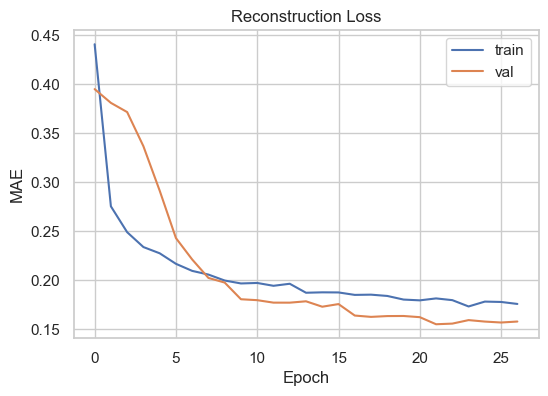

In [25]:
batch_size = 64
epochs = 50
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Shuffle globally for unsupervised training; keep copy for visualization mapping
perm = np.random.RandomState(42).permutation(X.shape[0])
X_shuf = X[perm]
sid_shuf = sid[perm]
start_idx_shuf = start_idx[perm]

# Train/val split
n = X_shuf.shape[0]
n_train = int(0.8 * n)
X_train, X_val = X_shuf[:n_train], X_shuf[n_train:]

hist = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[es],
    verbose=1
)
# Plot loss
plt.figure(figsize=(6,4))
plt.plot(hist.history['loss'], label='train')
plt.plot(hist.history['val_loss'], label='val')
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

## Latent States and Reconstruction Error
We extract latent vectors summarizing each window and visualize them with t-SNE, along with reconstruction errors as a proxy for atypical (possibly stressed) states.

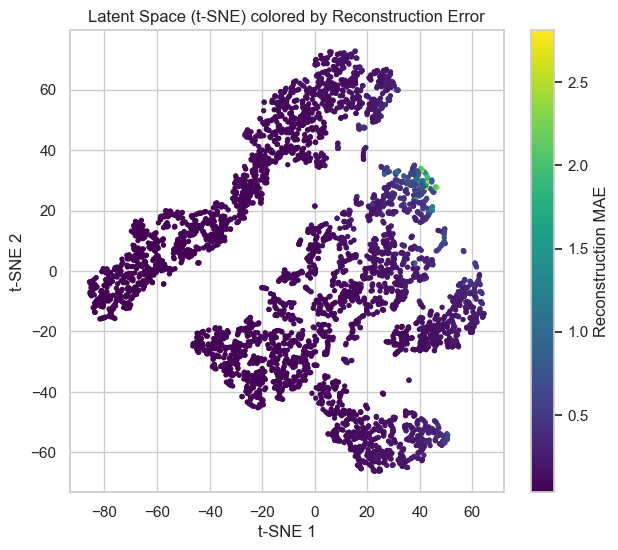

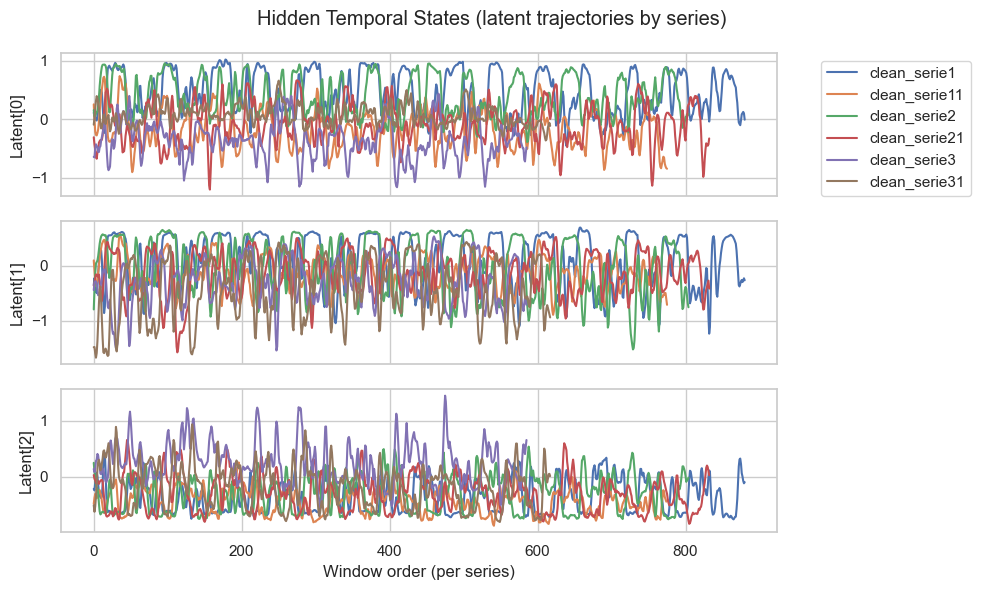

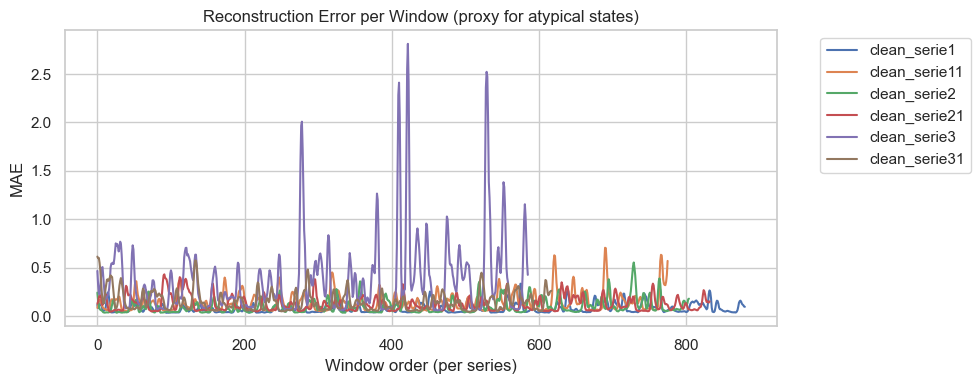

In [27]:
# Latent vectors for all windows (original order)
latent_all = encoder.predict(X, verbose=0)  # (N, latent_dim)
recon_all = autoencoder.predict(X, verbose=0)  # (N, T, C)
# Reconstruction error per window (mean absolute error)
mae_per_window = np.mean(np.abs(recon_all - X), axis=(1,2))

# t-SNE embedding
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max(5, X.shape[0]//50)))
Z = tsne.fit_transform(latent_all)

plt.figure(figsize=(7,6))
plt.scatter(Z[:,0], Z[:,1], c=mae_per_window, cmap='viridis', s=8)
plt.colorbar(label='Reconstruction MAE')
plt.title('Latent Space (t-SNE) colored by Reconstruction Error')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

# Per-series latent trajectories over window index
latent_dim = latent_all.shape[1]
dims_to_plot = min(3, latent_dim)
fig, axes = plt.subplots(dims_to_plot, 1, figsize=(10, 6), sharex=True)
if dims_to_plot == 1:
    axes = [axes]
for d in range(dims_to_plot):
    for s in range(len(series_names)):
        mask = (sid == s)
        plt_idx = np.argsort(start_idx[mask])
        axes[d].plot(np.arange(np.sum(mask)), latent_all[mask][plt_idx, d], label=series_names[s])
    axes[d].set_ylabel(f'Latent[{d}]')
axes[-1].set_xlabel('Window order (per series)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle('Hidden Temporal States (latent trajectories by series)')
plt.tight_layout()
plt.show()

# Reconstruction error over time per series
plt.figure(figsize=(10,4))
for s in range(len(series_names)):
    mask = (sid == s)
    plt_idx = np.argsort(start_idx[mask])
    plt.plot(np.arange(np.sum(mask)), mae_per_window[mask][plt_idx], label=series_names[s])
plt.title('Reconstruction Error per Window (proxy for atypical states)')
plt.xlabel('Window order (per series)')
plt.ylabel('MAE')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# CNN + LSTM Autoencoder on Raw EEG (Unsupervised)

This notebook builds a 1D-CNN + LSTM autoencoder to learn temporal and frequency representations from unlabeled EEG signals.

It constructs the cleaned DataFrames expected elsewhere in the project: `clean_serie1`, `clean_serie11`, `cleaan_serie2` (intentional name per request), `clean_serie21`, `clean_serie3`, `clean_serie31`.

We then window the multichannel time series, train an unsupervised autoencoder, and visualize hidden temporal states that may correspond to stress variations using latent embeddings and reconstruction error.

Note: This notebook is self-contained and loads data from the `data/` directory.

In [28]:
# Imports
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

print(tf.__version__)
sns.set(style='whitegrid')

2.19.0


## Build a unified multichannel dataset
We align common EEG channels across DataFrames and generate overlapping windows for unsupervised training.

In [29]:
series = [clean_serie1, clean_serie11, clean_serie2, clean_serie21, clean_serie3, clean_serie31]
series_names = ['clean_serie1', 'clean_serie11', 'clean_serie2', 'clean_serie21', 'clean_serie3', 'clean_serie31']

# Determine common EEG columns (exclude 'Time')
def common_channels(dfs):
    cols = None
    for df in dfs:
        eeg_cols = [c for c in df.columns if c != 'Time']
        cols = set(eeg_cols) if cols is None else (cols & set(eeg_cols))
    return sorted(list(cols)) if cols else []

channels = common_channels(series)
if len(channels) == 0:
    raise RuntimeError('No common EEG channels found across series. Please check column names in CSVs.')
print('Using channels (common across all series):', channels)
n_channels = len(channels)

def df_to_array(df: pd.DataFrame, channels: list) -> np.ndarray:
    X = df[channels].to_numpy(dtype=np.float32)
    return X

def window_array(X: np.ndarray, window_size: int, step: int) -> np.ndarray:
    n = X.shape[0]
    idxs = list(range(0, max(n - window_size + 1, 0), step))
    windows = [X[i:i+window_size] for i in idxs if i + window_size <= n]
    return np.stack(windows, axis=0) if windows else np.empty((0, window_size, X.shape[1]), dtype=X.dtype), np.array(idxs)

# Parameters
window_sec = 2.0
step_sec = 0.5
win = int(round(window_sec * sfreq))
stp = int(round(step_sec * sfreq))
print('Window size (samples):', win, 'Step (samples):', stp)

X_windows = []
series_ids = []
series_time_idx = []
for s_idx, (name, df) in enumerate(zip(series_names, series)):
    Xa = df_to_array(df, channels)
    Ws, starts = window_array(Xa, win, stp)
    if Ws.shape[0] == 0:
        continue
    X_windows.append(Ws)
    series_ids.append(np.full((Ws.shape[0],), s_idx))
    series_time_idx.append(starts)

if not X_windows:
    raise RuntimeError('No windows could be created. Check window size/step vs data length.')

X = np.concatenate(X_windows, axis=0)  # (N, T, C)
sid = np.concatenate(series_ids, axis=0)
start_idx = np.concatenate(series_time_idx, axis=0)
print('Windows shape:', X.shape, '| Total windows:', X.shape[0])

# Standardize per-channel over all windows
scaler = StandardScaler(with_mean=True, with_std=True)
X_2d = X.reshape(-1, n_channels)
X_2d = scaler.fit_transform(X_2d)
X = X_2d.reshape(X.shape[0], X.shape[1], n_channels).astype(np.float32)
print('Standardized windows.')

Using channels (common across all series): ['Alpha_C3', 'Alpha_C4', 'Alpha_F3', 'Alpha_F4', 'Alpha_Fz', 'Alpha_O1', 'Alpha_O2', 'Alpha_Pz', 'Beta_C3', 'Beta_C4', 'Beta_F3', 'Beta_F4', 'Beta_Fz', 'Beta_O1', 'Beta_O2', 'Beta_Pz', 'Delta_C3', 'Delta_C4', 'Delta_F3', 'Delta_F4', 'Delta_Fz', 'Delta_O1', 'Delta_O2', 'Delta_Pz', 'Gamma_C3', 'Gamma_C4', 'Gamma_F3', 'Gamma_F4', 'Gamma_Fz', 'Gamma_O1', 'Gamma_O2', 'Gamma_Pz', 'Theta_C3', 'Theta_C4', 'Theta_F3', 'Theta_F4', 'Theta_Fz', 'Theta_O1', 'Theta_O2', 'Theta_Pz']
Window size (samples): 120 Step (samples): 30
Windows shape: (4499, 120, 40) | Total windows: 4499
Standardized windows.


## Build CNN + LSTM Autoencoder
Temporal Conv1D layers capture frequency-like local patterns; the LSTM layers learn temporal dependencies across the window.

In [30]:
input_shape = (X.shape[1], X.shape[2])  # (T, C)

def build_cnn_lstm_autoencoder(input_shape, latent_dim=32):
    inp = layers.Input(shape=input_shape)
    # Encoder: temporal convs
    x = layers.Conv1D(32, 7, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 5, padding='same', activation='relu', dilation_rate=2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu', dilation_rate=4)(x)
    x = layers.BatchNormalization()(x)
    # Sequence encoder
    x_seq = layers.LSTM(64, return_sequences=True)(x)
    latent_seq = layers.TimeDistributed(layers.Dense(latent_dim))(x_seq)
    # Global latent vector for visualization (temporal summary)
    latent_vec = layers.GlobalAveragePooling1D()(latent_seq)

    # Decoder
    y = layers.LSTM(64, return_sequences=True)(latent_seq)
    y = layers.Conv1D(64, 3, padding='same', activation='relu')(y)
    y = layers.BatchNormalization()(y)
    y = layers.Conv1D(32, 5, padding='same', activation='relu')(y)
    y = layers.BatchNormalization()(y)
    out = layers.Conv1D(input_shape[1], 1, padding='same', activation='linear')(y)

    auto = Model(inp, out, name='cnn_lstm_autoencoder')
    enc = Model(inp, latent_vec, name='encoder_latent')
    auto.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mae')
    return auto, enc

autoencoder, encoder = build_cnn_lstm_autoencoder(input_shape, latent_dim=32)
autoencoder.summary()

Model: "cnn_lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 120, 32)        │         8,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 120, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 120, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 120, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 120, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 120, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 120, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 120, 32)        │         2,080 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 120, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 120, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 120, 32)        │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 120, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 120, 40)        │         1,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,552 (455.28 KB)

 Trainable params: 116,040 (453.28 KB)

 Non-trainable params: 512 (2.00 KB)

## Unsupervised Stress-State Clustering
We cluster the latent embeddings to infer discrete brain states. Higher average reconstruction error within a cluster may indicate more stressed states. We select K via silhouette score over a small range and provide GMM+BIC as a reference.

Silhouette scores: {2: np.float64(0.386), 3: np.float64(0.306), 4: np.float64(0.259), 5: np.float64(0.283), 6: np.float64(0.286), 7: np.float64(0.28), 8: np.float64(0.272)}
Selected K (KMeans): 2
GMM BIC (lower is better): {2: np.float64(-319300.3), 3: np.float64(-362627.8), 4: np.float64(-409487.4), 5: np.float64(-430300.2), 6: np.float64(-448231.1), 7: np.float64(-455172.7), 8: np.float64(-452803.4)}
Cluster summary (sorted by mean MAE):
   state_id     n  mean_mae  median_mae
1         1  3270  0.191673    0.136225
0         0  1229  0.054799    0.053472
Per-series state counts:
state_id         0    1
series_name            
clean_serie1   471  410
clean_serie11  107  669
clean_serie2   366  439
clean_serie21  182  651
clean_serie3    13  573
clean_serie31   90  528


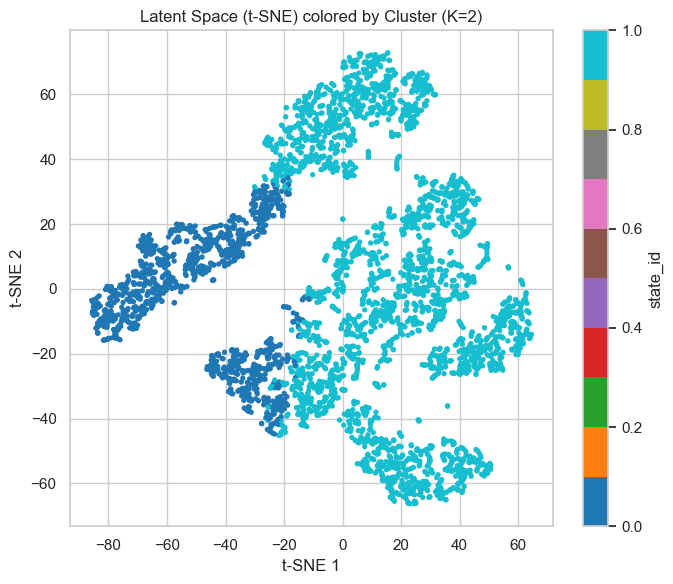

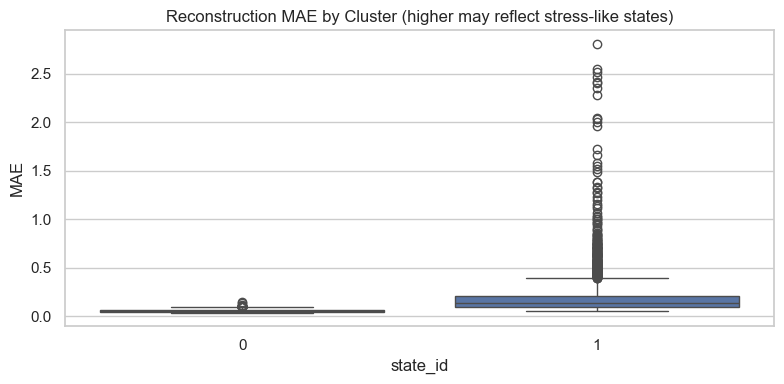

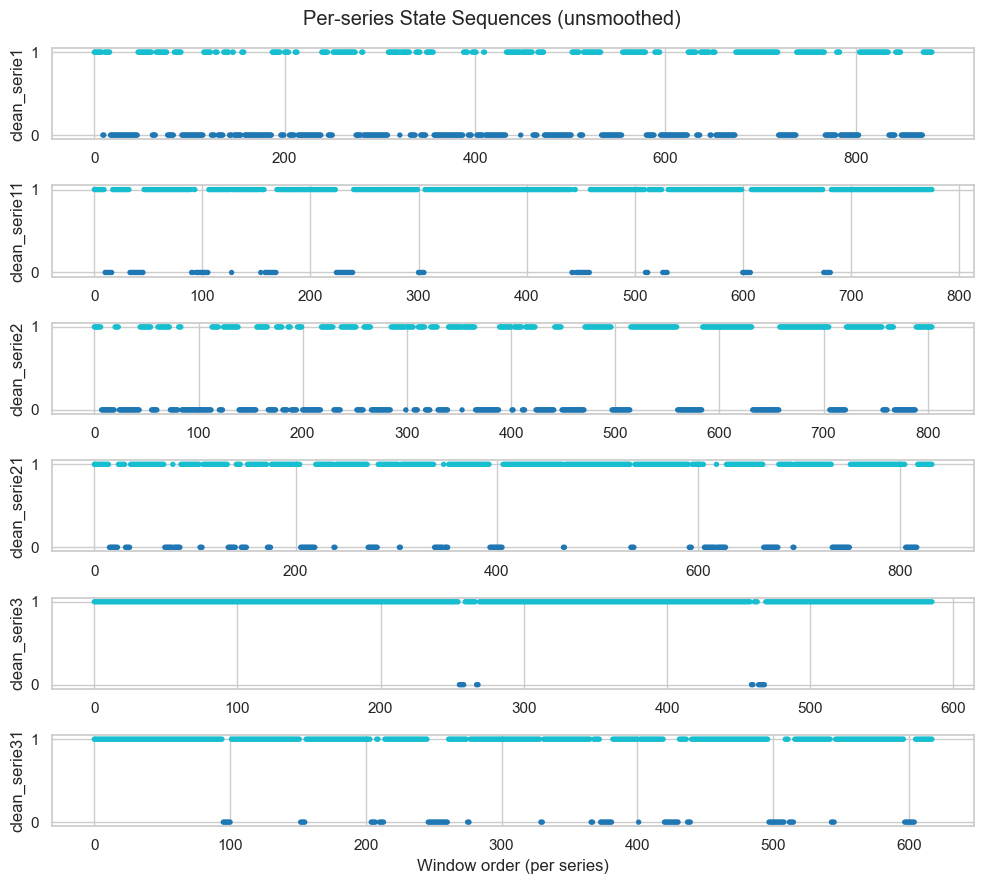

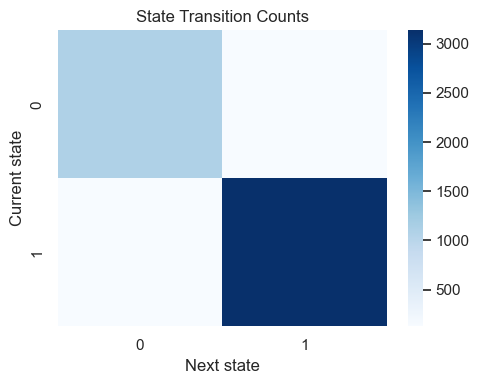

Saved: data\states_per_window.csv
Saved: data\state_summary.csv


In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

# 1) Choose K via silhouette on latent vectors
k_range = list(range(2, 9))
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels_k = km.fit_predict(latent_all)
    if len(set(labels_k)) > 1:
        sil = silhouette_score(latent_all, labels_k)
    else:
        sil = -1
    sil_scores.append(sil)

best_k = k_range[int(np.argmax(sil_scores))]
print('Silhouette scores:', dict(zip(k_range, np.round(sil_scores, 3))))
print('Selected K (KMeans):', best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
state_id = kmeans.fit_predict(latent_all)

# 2) Optional reference: GMM with BIC
bic_scores = []
for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(latent_all)
    bic_scores.append(gmm.bic(latent_all))
print('GMM BIC (lower is better):', dict(zip(k_range, np.round(bic_scores, 1))))

# 3) Collect per-window state data
states_df = pd.DataFrame({
    'window_idx_global': np.arange(len(state_id)),
    'series_id': sid,
    'series_name': [series_names[i] for i in sid],
    'start_idx': start_idx,
    'state_id': state_id,
    'recon_mae': mae_per_window,
})

# 4) Cluster diagnostics
summary = states_df.groupby('state_id').agg(
    n=('window_idx_global', 'count'),
    mean_mae=('recon_mae', 'mean'),
    median_mae=('recon_mae', 'median')
).reset_index().sort_values(['mean_mae'], ascending=False)
print('Cluster summary (sorted by mean MAE):')
print(summary)

# Heuristic: mark top-quantile mean MAE clusters as potentially stressed
q75 = summary['mean_mae'].quantile(0.75)
summary['stress_like'] = summary['mean_mae'] >= q75

# Per-series distribution
per_series = states_df.pivot_table(index='series_name', columns='state_id', values='window_idx_global', aggfunc='count', fill_value=0)
print('Per-series state counts:')
print(per_series)

# 5) Dwell time and transition analysis

def compute_transitions(df_one_series: pd.DataFrame):
    df_sorted = df_one_series.sort_values('start_idx')
    s = df_sorted['state_id'].to_numpy()
    # dwell lengths
    dwell = []
    if len(s) > 0:
        cur = s[0]; count = 1
        for x in s[1:]:
            if x == cur:
                count += 1
            else:
                dwell.append((cur, count))
                cur = x; count = 1
        dwell.append((cur, count))
    # transitions
    trans = []
    for a, b in zip(s[:-1], s[1:]):
        trans.append((a, b))
    return dwell, trans

# Build transition matrix
K = int(summary['state_id'].max() + 1) if len(summary) else int(state_id.max() + 1)
T = np.zeros((K, K), dtype=int)
all_dwells = []
for s_i in range(len(series_names)):
    dfi = states_df[states_df.series_id == s_i]
    dwell, trans = compute_transitions(dfi)
    all_dwells.extend(dwell)
    for a, b in trans:
        T[a, b] += 1

# 6) Visualizations
plt.figure(figsize=(7,6))
scatter = plt.scatter(Z[:,0], Z[:,1], c=state_id, cmap='tab10', s=8)
plt.title(f'Latent Space (t-SNE) colored by Cluster (K={best_k})')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.colorbar(scatter, label='state_id')
plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=states_df['state_id'], y=states_df['recon_mae'])
plt.title('Reconstruction MAE by Cluster (higher may reflect stress-like states)')
plt.xlabel('state_id'); plt.ylabel('MAE')
plt.tight_layout(); plt.show()

# Per-series state sequences (raster)
fig, axes = plt.subplots(len(series_names), 1, figsize=(10, 1.5*len(series_names)), sharex=False)
if len(series_names) == 1:
    axes = [axes]
for s_i, ax in enumerate(axes):
    dfi = states_df[states_df.series_id == s_i].sort_values('start_idx')
    ax.scatter(np.arange(len(dfi)), dfi['state_id'], c=dfi['state_id'], cmap='tab10', s=8)
    ax.set_ylabel(series_names[s_i])
    ax.set_yticks(range(K))
    ax.set_yticklabels(range(K))
axes[-1].set_xlabel('Window order (per series)')
fig.suptitle('Per-series State Sequences (unsmoothed)')
plt.tight_layout(); plt.show()

# Transition heatmap
plt.figure(figsize=(5,4))
sns.heatmap(T, annot=False, cmap='Blues', cbar=True)
plt.title('State Transition Counts')
plt.xlabel('Next state'); plt.ylabel('Current state')
plt.tight_layout(); plt.show()

# 7) Save outputs
os.makedirs(DATA_DIR, exist_ok=True)
states_path = os.path.join(DATA_DIR, 'states_per_window.csv')
summary_path = os.path.join(DATA_DIR, 'state_summary.csv')
states_df.to_csv(states_path, index=False)
summary.to_csv(summary_path, index=False)
print(f'Saved: {states_path}')
print(f'Saved: {summary_path}')